<center> <b> <h1> Swiggy Food Delivery ML-Analysis Project </h1> </b> </center>

In [1]:
#Import the required libraries:
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold,
    StratifiedKFold,
    GridSearchCV
)


from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from xgboost import XGBRegressor








from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from xgboost import XGBClassifier


from sklearn.tree import plot_tree


from sklearn.metrics import (
    # Classification Metrics
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,

    # Regression Metrics
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


warnings.filterwarnings("ignore")

In [2]:
#Load the dataset:
df = pd.read_csv("dataset/swiggy.csv")
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [3]:
#Check for any null-values:
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [4]:
#Check for any duplicate values:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [6]:
#View basic information about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


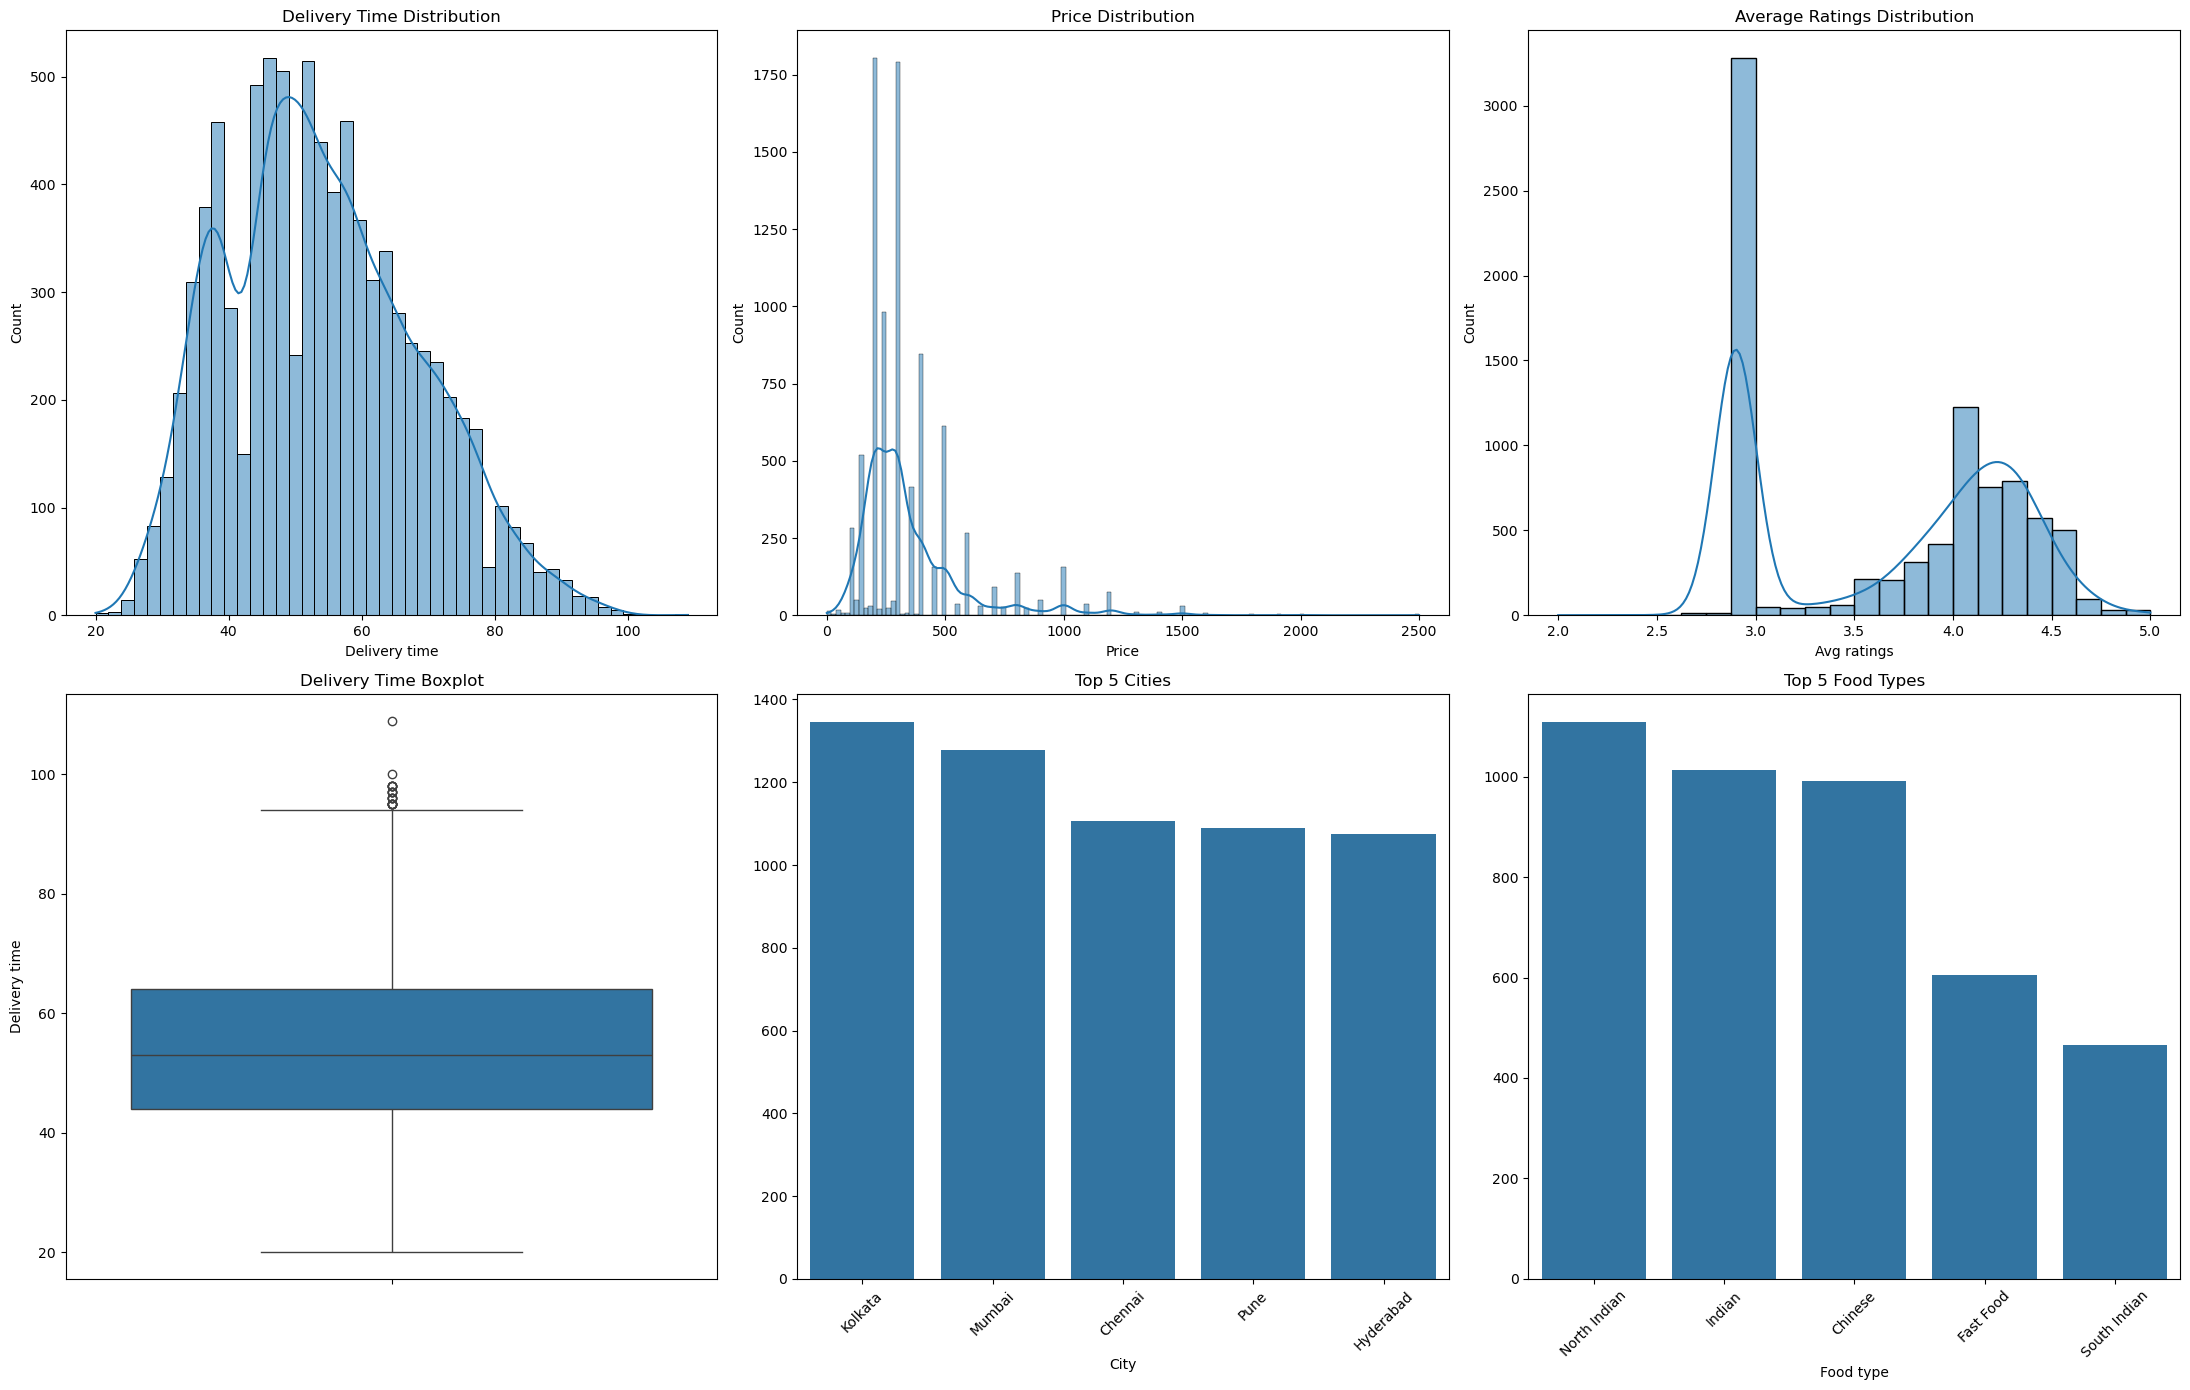

In [7]:
df['Food type'] = df['Food type'].str.split(',').str[0]
# Basic EDA:

plt.figure(figsize=(22, 14))
# 1. Delivery Time Distribution
plt.subplot(2, 3, 1)
sns.histplot(df['Delivery time'], kde=True)
plt.title("Delivery Time Distribution")


# 2. Price Distribution
plt.subplot(2, 3, 2)
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")


# 3. Average Ratings Distribution
plt.subplot(2, 3, 3)
sns.histplot(df['Avg ratings'], kde=True)
plt.title("Average Ratings Distribution")


# ========== ROW 2 ==========

# 4. Delivery Time Boxplot
plt.subplot(2, 3, 4)
sns.boxplot(y=df['Delivery time'])
plt.title("Delivery Time Boxplot")


# 5. Top 5 Cities Count
plt.subplot(2, 3, 5)

top_cities = df['City'].value_counts().head(5)

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.title("Top 5 Cities")
plt.xticks(rotation=45)


# 6. Top 5 Food Types Count
plt.subplot(2, 3, 6)

top_food_types = df['Food type'].value_counts().head(5)

sns.barplot(
    x=top_food_types.index,
    y=top_food_types.values
)

plt.title("Top 5 Food Types")
plt.xticks(rotation=45)


# Adjust layout
plt.tight_layout()

plt.show()

<h4> <center> Hypothesis Testing Questions </center> </h4>

#### Q1] Swiggy wants to determine whether the average delivery time of restaurants on its platform differs significantly from the company's target delivery time of 45 minutes. (one sample ttest)

In [8]:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(
    df["Delivery time"],
    popmean=45
)

alpha = 0.05

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < alpha:
    print(
        "Reject H0: The average delivery time is "
        "significantly different from 45 minutes."
    )
else:
    print(
        "Fail to reject H0: There is insufficient evidence "
        "to conclude that the average delivery time differs "
        "from 45 minutes."
    )

T-statistic: 58.45293269374849
P-value: 0.0
Reject H0: The average delivery time is significantly different from 45 minutes.


#### Q2] Swiggy wants to determine whether Indian restaurants and Chinese restaurants have significantly different average delivery times. (welch's independent two-sample ttest)

In [9]:
from scipy.stats import ttest_ind

indian_delivery = df[
    df["Food type"] == "Indian"
]["Delivery time"]

chinese_delivery = df[
    df["Food type"] == "Chinese"
]["Delivery time"]

t_stat, p_value = ttest_ind(
    indian_delivery,
    chinese_delivery,
    equal_var=False
)

alpha = 0.05

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < alpha:
    print(
        "Reject H0: Indian and Chinese restaurants have "
        "significantly different average delivery times."
    )
else:
    print(
        "Fail to reject H0: There is insufficient evidence "
        "of a significant difference in average delivery times."
    )

T-statistic: -1.8359413558440552
P-value: 0.06651459354665748
Fail to reject H0: There is insufficient evidence of a significant difference in average delivery times.


#### Q3] Swiggy wants to determine whether the average customer rating of restaurants on its platform is significantly different from 4.0, which is considered the company's benchmark for a well-performing restaurant. (one sample ttest)

In [10]:
#Since the population standard deviation of restaurant ratings is unknown, t-Test is used.

from scipy.stats import ttest_1samp

t_stat , p_value = ttest_1samp(a=df["Avg ratings"], popmean=4)

if p_value < 0.05:
    print("Average customer rating is significantly different from 4")
else:
    print("There is insufficient evidence to conclude that the average rating differs from 4.0")

Average customer rating is significantly different from 4


#### Q4] Swiggy wants to determine whether Indian restaurants and Chinese restaurants have significantly different average customer ratings. (welch ttest)

In [11]:
from scipy.stats import ttest_ind

indian_ratings = df[df['Food type'] == 'Indian']['Avg ratings']
chinese_ratings = df[df['Food type'] == 'Chinese']['Avg ratings']

t_stat , p_value = ttest_ind(a=indian_ratings, b=chinese_ratings, equal_var=False)

if p_value < 0.05:
    print("Both restaurants have significantly different average customer ratings.")
else:
    print("There is insufficient evidence of a significant difference in average customer ratings.")

There is insufficient evidence of a significant difference in average customer ratings.


#### Q5] Swiggy wants to determine whether the average delivery time differs significantly among Indian, Chinese, and Fast Food restaurants. (one-way anova)

In [12]:
from scipy.stats import f_oneway

#Boolean masks of all food types:
indian_mask = df['Food type'].str.contains('Indian', case=False, na=False)
chinese_mask = df['Food type'].str.contains('Chinese', case=False, na=False)
fast_food_mask = df['Food type'].str.contains('Fast Food', case=False, na=False)

#Delivery time obtained from food-types:
indian = df.loc[indian_mask, 'Delivery time']
chinese = df.loc[chinese_mask, 'Delivery time']
fast_food = df.loc[fast_food_mask, 'Delivery time']

f_stat, p_value = f_oneway(indian, chinese, fast_food)


if p_value < 0.05:
    print("Reject the Null Hypothesis: At least one cuisine type has a significantly different average delivery time.")
else:
    print("Fail to Reject the Null Hypothesis: There is insufficient evidence that average delivery times differ among the groups.")

Reject the Null Hypothesis: At least one cuisine type has a significantly different average delivery time.


#### Q6] Swiggy wants to determine whether restaurant cuisine type is associated with the city in which the restaurant operates. (Chi-Square Test of Independence)

In [13]:
from scipy.stats import chi2_contingency


table = pd.crosstab(
    df["City"],
    df["Food type"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

alpha = 0.05

percentage_below_5 = (
    (expected < 5).sum() / expected.size
) * 100


if percentage_below_5 > 20:
    print("Chi-Square test assumption is violated because more than 20% of the expected frequencies are less than 5.")
else:
    if p_value < alpha:
        print(
            "Reject H0: There is a statistically significant "
            "association between food type and city."
        )
    else:
        print(
            "Fail to reject H0: There is insufficient evidence "
            "of an association between food type and city."
        )

Chi-Square test assumption is violated because more than 20% of the expected frequencies are less than 5.


<h4> <center> Machine Learning Questions </center> </h4>

### Q1] Predict the Delivery time of an order using restaurant, pricing, ratings, and location features.

In [14]:
#Feature / Target Split:
X = df.drop(columns=['Delivery time', 'ID', 'Food type'])
y = df['Delivery time']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Preprocessing:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


In [15]:


#Linear Regression:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])


#KNN Regressor:
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsRegressor())
])


#Decision-tree Regressor:
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])


#Extra-trees Regressor:
et_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', ExtraTreesRegressor(n_estimators=250, max_depth=5, random_state=42))
])


#Adaboost:
ada_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=7),
        n_estimators=400,
        learning_rate=0.5,
        random_state=42
    ))
])


#XG-Boost:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [16]:
#Model dictionary:
models = {
    "Linear Regression": lr_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dt_pipeline,
    "Extra Trees": et_pipeline,
    "AdaBoost": ada_pipeline,
    "XGBoost":xgb_pipeline
}

In [17]:
#Cross validation:


kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

results = []

for name, model in models.items():
    
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring
    )
    
    mae = -np.mean(cv_results['test_mae'])
    rmse = -np.mean(cv_results['test_rmse'])
    r2 = np.mean(cv_results['test_r2'])
    
    results.append({
        "Model": name,
        "CV R2": round(r2, 4),
        "CV MAE": round(mae, 2),
        "CV RMSE": round(rmse, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="CV R2", ascending=False)
print(results_df)

               Model   CV R2  CV MAE  CV RMSE
5            XGBoost  0.6644    6.33     8.25
1                KNN  0.6505    6.27     8.42
2      Decision Tree  0.5216    7.22     9.85
0  Linear Regression  0.4763    7.69    10.26
3        Extra Trees  0.3527    9.18    11.46
4           AdaBoost  0.3438    9.47    11.54


In [18]:
#Train the best model on Full-training data:
best_model = results_df.iloc[0]['Model']
print("Best Model:", best_model)

best_pipeline = models[best_model]
best_pipeline.fit(X_train, y_train)

Best Model: XGBoost


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Price', 'Avg ratings', 'Total ratings'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Area', 'City', 'Restaurant', 'Address'], dtype='object'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None,...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [19]:
#Test Evaluation on testing:


y_pred = best_pipeline.predict(X_test)

print("TEST RESULTS")
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

TEST RESULTS
R2: 0.675024151802063
MAE: 6.412059307098389
RMSE: 8.241580250142036


In [20]:
#Now test on one single tuple:
single_data = pd.DataFrame({
    'Area': ['Andheri East'],
    'City': ['Mumbai'],
    'Restaurant': ['Kung Fu Panda'],
    'Price': [600],
    'Avg ratings': [4.3],
    'Address': ['Marol'],
    'Total ratings': [100]
})

pred = best_pipeline.predict(single_data)
print("Predicted Delivery Time:", round(pred[0]), "minutes")

Predicted Delivery Time: 51 minutes


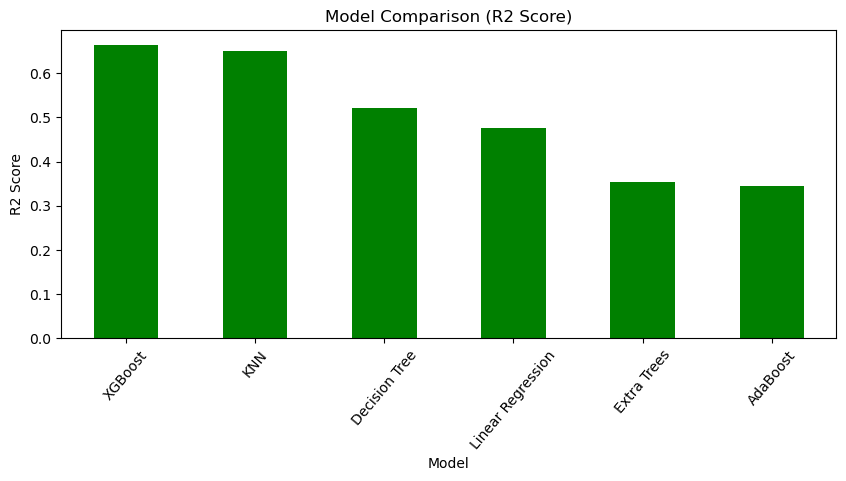

In [21]:
#Model comparison:

plt.figure(figsize=(10,4))
results_df.set_index("Model")["CV R2"].plot(kind='bar',color="green")
plt.title("Model Comparison (R2 Score)")

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=50)
plt.show()

In [22]:
#Export the best-performing model:

joblib.dump(best_pipeline,"Swiggy_FoodDeliveryTimePrediction_Model.pkl")

['Swiggy_FoodDeliveryTimePrediction_Model.pkl']

## CONCLUSION : We used several traditional-ml algorithms to predict the **delivery time**. The predicted **delivery time** is 51 minutes.

### Q2] Can we classify whether a restaurant will have fast or slow delivery based on its price, ratings, and popularity?

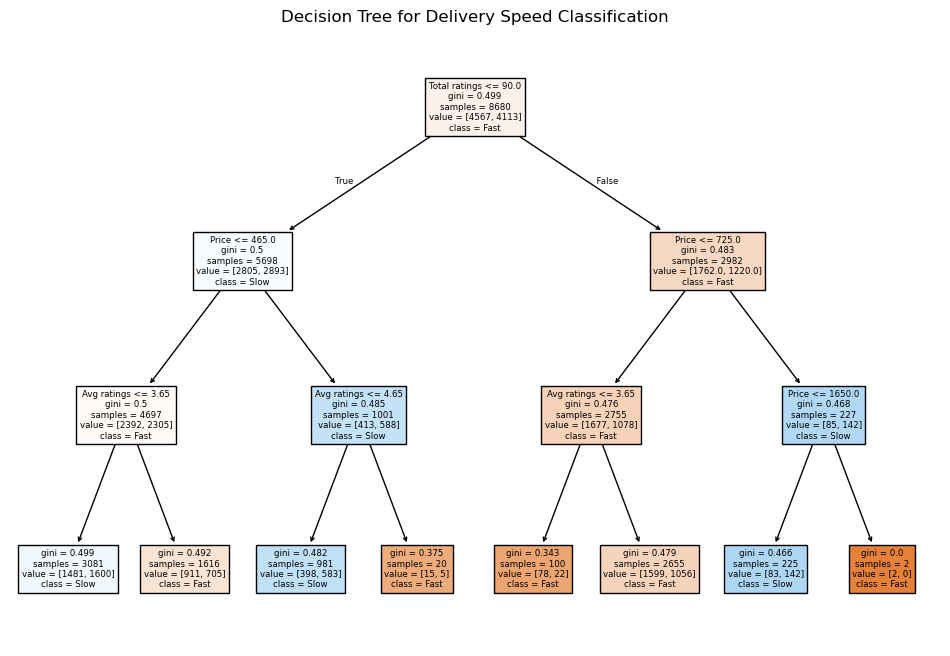

In [23]:
df['delivery_speed'] = df['Delivery time'].apply(
    lambda x: 'Fast' if x <= df['Delivery time'].median() else 'Slow'
)


X = df[['Price', 'Avg ratings', 'Total ratings']]
y = df['delivery_speed']




model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)



plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Fast', 'Slow'],
    filled=True
)
plt.title("Decision Tree for Delivery Speed Classification")
plt.show()

## CONCLUSION] 
- Expensive Restaurants tend to deliver food faster.
- Restaurants having a more preference (based on average user ratings) tend to deliver food faster.
- Restaurants having low ratings (based on average user ratings) tend to deliver food slower.

In [24]:
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time,delivery_speed
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,Biryani,5Th Block,59,Slow
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,Mughlai,5Th Block,56,Slow
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50,Fast
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,North Indian,80 Feet Road,57,Slow
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,Rajasthani,80 Feet Road,63,Slow


### Q3] Predict whether a restaurant belongs to the Premium or Budget segment:

In [25]:
df['price_segment'] = df['Price'].apply(lambda x: 'Premium' if x > 500 else 'Budget')

print("Check for imbalance in 'price_segment' attribute:")
print(df.price_segment.value_counts())
print("\n\n\n\n\n\n")




X = df.drop(columns=['price_segment','Price', 'ID', 'delivery_speed','Delivery time'])
y = df['price_segment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
])


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# All CLassification Pipelines:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
])



et_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', ExtraTreesClassifier(n_estimators=120, max_depth=9, n_jobs=-1,random_state=42))
])


ada_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=4),
        n_estimators=200, 
        learning_rate=0.8,
        random_state=42
    ))
])

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='logloss'
    ))
])





# Cross Validation:
## Model Dictionary:

models = {
    "Logistic Regression": lr_pipeline,
    "KNN Classifier": knn_pipeline,
    "Extra Trees": et_pipeline,
    "AdaBoost": ada_pipeline,
    "XGBoost": xgb_pipeline
}

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)   # 3 folds = faster
scoring = ['accuracy', 'f1_weighted']

results = []

for name, model in models.items():
    print(f"Running {name}...")
    
    cv_results = cross_validate(
        model, 
        X_train, 
        y_train_encoded,
        cv=kf, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "CV Accuracy": round(np.mean(cv_results['test_accuracy']), 4),
        "CV F1 Score": round(np.mean(cv_results['test_f1_weighted']), 4)
    })

results_df = pd.DataFrame(results).sort_values(by="CV Accuracy", ascending=False)
print("\n" + "="*50)
print(results_df)

Check for imbalance in 'price_segment' attribute:
price_segment
Budget     7665
Premium    1015
Name: count, dtype: int64







Running Logistic Regression...
Running KNN Classifier...
Running Extra Trees...
Running AdaBoost...
Running XGBoost...

                 Model  CV Accuracy  CV F1 Score
0  Logistic Regression       0.8914       0.8563
3             AdaBoost       0.8903       0.8545
4              XGBoost       0.8872       0.8595
2          Extra Trees       0.8831       0.8282
1       KNN Classifier       0.8800       0.8488


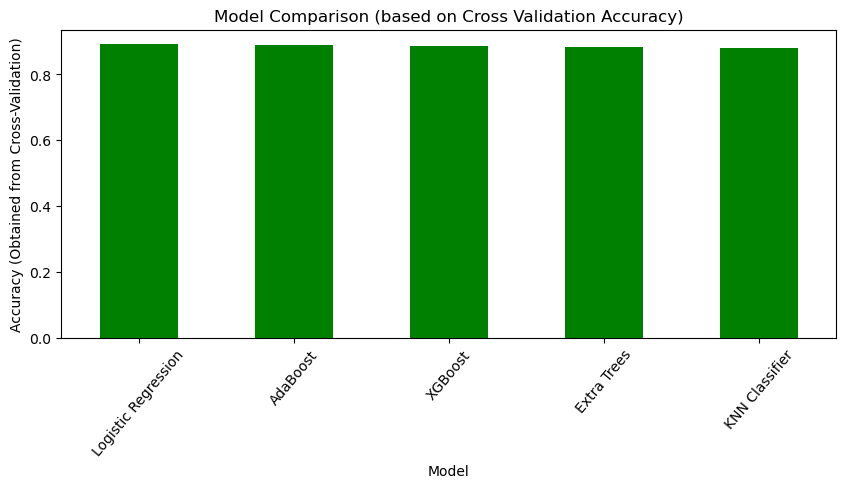

In [26]:
#Model comparison:
plt.figure(figsize=(10,4))
results_df.set_index("Model")["CV Accuracy"].plot(kind='bar',color="green")
plt.title("Model Comparison (based on Cross Validation Accuracy)")

plt.xlabel("Model")
plt.ylabel("Accuracy (Obtained from Cross-Validation)")
plt.xticks(rotation=50)
plt.show()

In [27]:
#Now test on one single tuple:
# ================== Test on One Single Tuple ==================
single_data = pd.DataFrame({
    'Area': ['Indiranagar'],
    'City': ['Bangalore'],
    'Restaurant': ['Chinita Real Mexican Food'],
    'Avg ratings': [4.5],
    'Total ratings': [500],
    'Food type': ['Mexican'],
    'Address': ['Double Road']
})

# Make prediction using the best model
lr_pipeline.fit(X_train, y_train)
pred = lr_pipeline.predict(single_data)
print("Predicted Price Segment:", pred[0])
print("Best Model Name : ",results_df.iloc[0]["Model"])

Predicted Price Segment: Premium
Best Model Name :  Logistic Regression


## CONCLUSION : We used several traditional-ml algorithms to predict the **price segment**. The predicted **price segment** is Premium.

In [28]:
#Export the best-performing model:

joblib.dump(lr_pipeline,"Price_Classification.pkl")

['Price_Classification.pkl']

### PROJECT BY:
- **Name:** Om Satyawan Pathak
- **Email:** omsatyawanpathakgit@gmail.com (or) omsatyawanpathakwebdevelopment@gmail.com
- **Linkedin:** www.linkedin.com/in/om-satyawan-pathak-029b02368